# Visual Question Answering on VQA v2.0

## A Comparative Study of CNN-LSTM Architectures with Attention Mechanisms

---

**Authors:** Anakonkai01  
**Date:** March 2026  
**Framework:** PyTorch 2.x · CUDA · Mixed Precision (BF16)  
**Hardware:** NVIDIA RTX 3060 (12 GB VRAM) · Intel i7-14700K · 64 GB RAM

---

### Abstract

This notebook implements and compares **four Visual Question Answering (VQA) architectures** on the VQA v2.0 dataset (Goyal et al., 2017). The task requires a model to take an image and a natural language question as input, then generate a natural language answer. We adopt an **encoder-decoder** framework in which a CNN encodes the image, an LSTM with attention pooling encodes the question, and a second LSTM decodes the answer token-by-token.

The four models are designed to **isolate the contribution** of two key design choices:
1. **Image encoder**: Scratch CNN vs. Pretrained ResNet-101 (transfer learning)
2. **Attention mechanism**: No attention (global feature vector) vs. Bahdanau spatial attention (49 image regions)

Training proceeds in **three phases** — teacher forcing, CNN fine-tuning, and scheduled sampling — to systematically improve performance while controlling for fair comparison.

### Model Architectures

| Model | Image Encoder | Spatial Features | Attention | Decoder | Key Hypothesis |
|-------|---------------|-----------------|-----------|---------|----------------|
| **A** | SimpleCNN (5 conv blocks, scratch) | No (1×1 global) | None | 2-layer LSTM | Baseline — can a scratch CNN learn VQA? |
| **B** | ResNet-101 (ImageNet pretrained, frozen→finetune) | No (1×1 global) | None | 2-layer LSTM | Does transfer learning improve over scratch? |
| **C** | SimpleCNNSpatial (5 conv blocks, scratch) | Yes (7×7 = 49 regions) | Bahdanau | 2-layer LSTM | Does attention help a weak encoder? |
| **D** | ResNet-101 Spatial (pretrained, frozen→finetune) | Yes (7×7 = 49 regions) | Bahdanau | 2-layer LSTM | Best-case: strong encoder + attention |

### Shared Components (v3.0)

All four models share the following design:

- **Question Encoder:** 2-layer LSTM with **Attention Pooling** — aggregates all token hidden states via a learned attention mechanism (not just the final hidden state), capturing information from all words in the question.
- **Gated Fusion:** Replaces element-wise Hadamard product. A sigmoid gate learns to blend image and question features: $\text{out} = \sigma(W[\mathbf{v};\mathbf{q}]) \odot \mathbf{v} + (1 - \sigma(W[\mathbf{v};\mathbf{q}])) \odot \mathbf{q}$, followed by LayerNorm for stable decoder initialization.
- **Decoder Init:** Only LSTM layer 0 receives the fusion vector as $h_0$; upper layers start from zeros.
- **L2 Normalization:** Both image and question features are L2-normalized before fusion to ensure consistent magnitude.

### Three-Phase Training Strategy

| Phase | Epochs | Technique | Learning Rate | Purpose |
|-------|--------|-----------|---------------|---------|
| **1 — Teacher Forcing** | 10 | Encoder frozen (B, D), data augmentation, answer sampling | 1×10⁻³ | Establish baseline convergence |
| **2 — Fine-tuning** | 5 | Unfreeze ResNet layer3+layer4 (B, D), differential LR | 5×10⁻⁴ | Adapt pretrained features to VQA domain |
| **3 — Scheduled Sampling** | 5 | Inverse-sigmoid ε decay (k=2), autoregressive exposure | 2×10⁻⁴ | Reduce exposure bias for inference |

### Optimization & Regularization

| Technique | Setting | Rationale |
|-----------|---------|-----------|
| Optimizer | AdamW (fused, decoupled weight decay) | Better generalization than Adam |
| Mixed Precision | BF16 (Ampere CC 8.6) | 2× throughput, no GradScaler needed |
| Gradient Accumulation | Effective batch = 256 | Consistent across all models despite VRAM constraints |
| LR Warmup | 1 epoch linear ramp (10% → 100%) | Prevent early training instability |
| LR Schedule | ReduceLROnPlateau (factor=0.5, patience=2) | Adaptive LR reduction on val loss plateau |
| Label Smoothing | 0.1 | Better probability calibration |
| Gradient Clipping | max_norm = 5.0 | Prevent gradient explosion |
| Dropout | 0.3 (embedding + LSTM inter-layer) | Regularization without over-suppression |
| Answer Sampling | Random 1-of-10 annotations per epoch | Data augmentation via label diversity |
| Image Augmentation | RandomHorizontalFlip + ColorJitter | Visual diversity |
| Early Stopping | patience = 3 | Prevent overfitting |

---

> **Instructions:** Run cells sequentially from top to bottom. Each section is independent once the previous section has completed. Checkpoints are saved automatically and support resumption.

---
## 1 · Environment Setup & GPU Verification

Before training, we verify that all software dependencies are installed and the GPU is correctly detected. The RTX 3060 features **Ampere architecture** (Compute Capability 8.6), which supports **BFloat16** mixed precision — this provides ~2× training throughput without the numerical instability issues of FP16 (no loss scaling required).

**Key checks:**
- PyTorch with CUDA support
- GPU VRAM ≥ 10 GB (RTX 3060 = 12 GB)
- BF16 support (CC ≥ 8.0)
- All Python dependencies (torchvision, PIL, tqdm, nltk, matplotlib)

In [1]:
import os, sys, json, glob, random

# ── Working directory ─────────────────────────────────────────────────────
PROJECT_ROOT = "/home/mayxin/workspace/DeepLearning/new_vqa"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src"))
print(f"CWD: {os.getcwd()}")

# ── PyTorch + GPU ─────────────────────────────────────────────────────────
import torch
print(f"\nPyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    cc  = torch.cuda.get_device_capability()
    vram_gb = gpu.total_memory / 1024**3
    bf16_ok = cc[0] >= 8
    print(f"GPU     : {gpu.name}")
    print(f"VRAM    : {vram_gb:.1f} GB")
    print(f"CC      : {cc[0]}.{cc[1]}")
    print(f"BF16    : {'YES — Ampere+' if bf16_ok else 'NO — FP16 fallback'}")
    if vram_gb < 10:
        print("WARNING: < 10 GB VRAM. Consider reducing batch_size.")
else:
    print("WARNING: No GPU. Training will be CPU-only (very slow).")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice  : {DEVICE}")

CWD: /home/mayxin/workspace/DeepLearning/new_vqa

PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : NVIDIA GeForce RTX 3060
VRAM    : 11.6 GB
CC      : 8.6
BF16    : YES — Ampere+

Device  : cuda

PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : NVIDIA GeForce RTX 3060
VRAM    : 11.6 GB
CC      : 8.6
BF16    : YES — Ampere+

Device  : cuda


In [2]:
# ── Dependency check ──────────────────────────────────────────────────────
import importlib
deps = {
    'torch'       : 'torch',
    'torchvision' : 'torchvision',
    'PIL'         : 'PIL',
    'tqdm'        : 'tqdm',
    'nltk'        : 'nltk',
    'matplotlib'  : 'matplotlib',
}
missing = []
for name, pkg in deps.items():
    try:
        importlib.import_module(pkg)
        print(f"  OK  {name}")
    except ImportError:
        print(f"  MISS {name}")
        missing.append(pkg)

if missing:
    print(f"\nRun:  pip install {' '.join(missing)}")
else:
    print("\nAll dependencies OK.")

  OK  torch
  OK  torchvision
  OK  PIL
  OK  tqdm
  OK  nltk
  OK  matplotlib

All dependencies OK.
  OK  torchvision
  OK  PIL
  OK  tqdm
  OK  nltk
  OK  matplotlib

All dependencies OK.


---
## 2 · Dataset: VQA v2.0 (MS-COCO)

### About the Dataset

The **VQA v2.0** dataset (Goyal et al., CVPR 2017) is the standard benchmark for visual question answering. It is built on top of MS-COCO images and contains:

| Split | Images | Questions | Annotations |
|-------|--------|-----------|-------------|
| **Train** (train2014) | 82,783 | 443,757 | 4,437,570 (10 per question) |
| **Validation** (val2014) | 40,504 | 214,354 | 2,143,540 (10 per question) |
| **Test** (test2015) | 81,434 | 447,793 | Not public |

Each question has **10 human-annotated answers** from different annotators, reflecting the inherent ambiguity in VQA. The official VQA accuracy metric accounts for this:

$$\text{VQA Accuracy} = \min\left(\frac{\text{\# annotators who gave that answer}}{3},\ 1.0\right)$$

### Data Structure

```
data/
├── train2014/train2014/      # ~83K training images (JPEG)
├── val2014/                  # ~40K validation images (JPEG)
├── vqa_data_json/
│   ├── v2_Questions_Train_mscoco/   # Questions → {question_id, image_id, question}
│   ├── v2_Annotations_Train_mscoco/ # Annotations → {answers[], multiple_choice_answer}
│   ├── v2_Questions_Val_mscoco/
│   └── v2_Annotations_Val_mscoco/
└── processed/
    ├── vocab_questions.json   # Question vocabulary (words ≥ 3 occurrences)
    └── vocab_answers.json     # Answer vocabulary (answers ≥ 5 occurrences)
```

### Data Verification

The following cell verifies that all required data files are present locally.

In [3]:
data_paths = {
    "Train images"      : "data/train2014/train2014",
    "Val images"        : "data/val2014",
    "Train questions"   : "data/vqa_data_json/v2_Questions_Train_mscoco/v2_OpenEnded_mscoco_train2014_questions.json",
    "Train annotations" : "data/vqa_data_json/v2_Annotations_Train_mscoco/v2_mscoco_train2014_annotations.json",
    "Val questions"     : "data/vqa_data_json/v2_Questions_Val_mscoco/v2_OpenEnded_mscoco_val2014_questions.json",
    "Val annotations"   : "data/vqa_data_json/v2_Annotations_Val_mscoco/v2_mscoco_val2014_annotations.json",
}

all_ok = True
print(f"{'Name':<22} {'Status':<8} {'Detail'}")
print("-" * 60)
for name, path in data_paths.items():
    exists = os.path.exists(path)
    if not exists:
        all_ok = False
        detail = "MISSING"
    elif os.path.isdir(path):
        n = len(glob.glob(os.path.join(path, "*.jpg")))
        detail = f"{n:,} images"
    else:
        detail = f"{os.path.getsize(path)/1024**2:.1f} MB"
    status = "OK" if exists else "MISSING"
    print(f"  {name:<20} {status:<8} {detail}")

print("-" * 60)
print("All data verified." if all_ok else "ERROR: Missing data files.")

Name                   Status   Detail
------------------------------------------------------------
  Train images         OK       82,783 images
  Val images           OK       40,504 images
  Train questions      OK       40.0 MB
  Train annotations    OK       339.0 MB
  Val questions        OK       19.3 MB
  Val annotations      OK       163.8 MB
------------------------------------------------------------
All data verified.
  Val images           OK       40,504 images
  Train questions      OK       40.0 MB
  Train annotations    OK       339.0 MB
  Val questions        OK       19.3 MB
  Val annotations      OK       163.8 MB
------------------------------------------------------------
All data verified.


---
## 3 · Vocabulary Construction

### Tokenization & Vocabulary Building

The VQA task requires two separate vocabularies:

1. **Question Vocabulary** — maps question words to integer indices
2. **Answer Vocabulary** — maps answer words to integer indices

Both vocabularies include four **special tokens** required for sequence-to-sequence decoding:

| Token | Index | Purpose |
|-------|-------|---------|
| `<pad>` | 0 | Pad shorter sequences in a batch to equal length |
| `<start>` | 1 | Signals the beginning of a sequence |
| `<end>` | 2 | Signals the end of a sequence (stop decoding) |
| `<unk>` | 3 | Replaces out-of-vocabulary (rare) words |

**Frequency thresholds** are applied to reduce vocabulary size and improve generalization:
- **Question words:** kept if they appear **≥ 3 times** across all training questions
- **Answer words:** kept if they appear **≥ 5 times** across all training annotations

Rare words below the threshold are replaced with `<unk>` during numericalization.

### Numericalization Example

```
Question: "What color is the cat?"
Tokens:   ["what", "color", "is", "the", "cat"]
Indices:  [1, 42, 156, 8, 12, 891, 2]  ← with <start> and <end>

Answer:   "black"
Indices:  [1, 73, 2]  ← [<start>, black, <end>]
```

**Skip the build step if vocabulary files already exist.**

In [4]:
vocab_q_path = "data/processed/vocab_questions.json"
vocab_a_path = "data/processed/vocab_answers.json"

if os.path.exists(vocab_q_path) and os.path.exists(vocab_a_path):
    vq = json.load(open(vocab_q_path))
    va = json.load(open(vocab_a_path))
    print(f"Vocab exists — skipping build.")
    print(f"  Question vocab : {len(vq['word2idx']):,} tokens")
    print(f"  Answer vocab   : {len(va['word2idx']):,} tokens")
else:
    print("Vocab not found. Run the next cell.")

Vocab exists — skipping build.
  Question vocab : 8,174 tokens
  Answer vocab   : 3,706 tokens


In [5]:
# Build vocabulary (~2-5 min)
!python src/scripts/1_build_vocab.py


1. Reading question file: data/vqa_data_json/v2_Questions_Train_mscoco/v2_OpenEnded_mscoco_train2014_questions.json
Building question vocabulary...
 -> Tokenizing...
Building question vocabulary...
 -> Tokenizing...
 -> Filtering (threshold=3)...
 -> Done. Vocab size: 8174
Done! Saved to: data/processed/vocab_questions.json

2. Reading annotation file: data/vqa_data_json/v2_Annotations_Train_mscoco/v2_mscoco_train2014_annotations.json
 -> Filtering (threshold=3)...
 -> Done. Vocab size: 8174
Done! Saved to: data/processed/vocab_questions.json

2. Reading annotation file: data/vqa_data_json/v2_Annotations_Train_mscoco/v2_mscoco_train2014_annotations.json
Building answer vocabulary...
 -> Tokenizing...
Building answer vocabulary...
 -> Tokenizing...
 -> Filtering (threshold=5)...
 -> Done. Vocab size: 3706
Done! Saved to: data/processed/vocab_answers.json
 -> Filtering (threshold=5)...
 -> Done. Vocab size: 3706
Done! Saved to: data/processed/vocab_answers.json


In [6]:
from vocab import Vocabulary
vocab_q = Vocabulary(); vocab_q.load(vocab_q_path)
vocab_a = Vocabulary(); vocab_a.load(vocab_a_path)
print(f"Question vocab : {len(vocab_q):,} tokens")
print(f"Answer vocab   : {len(vocab_a):,} tokens")

Question vocab : 8,174 tokens
Answer vocab   : 3,706 tokens


---
## 4 · Phase 1 — Teacher Forcing (10 Epochs)

### Objective

Establish baseline performance for all four models under **identical training conditions**. In this phase, the decoder receives the **ground-truth previous token** at every decode step (teacher forcing), which maximizes gradient signal quality and enables fast initial convergence.

### Pipeline Overview

The forward pass follows a consistent encoder–fusion–decoder pipeline:

```
┌──────────────┐     ┌──────────────────┐
│  Input Image │     │  Input Question   │
│ (3×224×224)  │     │  "What color...?" │
└──────┬───────┘     └────────┬──────────┘
       │                      │
  ┌────▼─────┐         ┌─────▼──────────┐
  │ CNN      │         │ Question LSTM   │
  │ Encoder  │         │ + Attn Pooling  │
  └────┬─────┘         └─────┬──────────┘
       │ img_feat             │ q_feat
       │  (B, H)              │ (B, H)
       │    L2-norm           │   L2-norm
       └───────┬──────────────┘
               │
        ┌──────▼──────┐
        │ GatedFusion  │  g = σ(W[v;q])
        │ + LayerNorm  │  out = g⊙v + (1-g)⊙q
        └──────┬──────┘
               │ fusion (B, H)
               │
        ┌──────▼──────┐
        │  h₀[0] = fusion   │  ← only layer 0
        │  h₀[1] = zeros    │  ← upper layers
        └──────┬──────┘
               │
        ┌──────▼──────┐     ┌─────────────┐
        │ LSTM Decoder │◄────│ Answer tokens│
        │ (2 layers)   │     │ <start> w₁ … │
        └──────┬──────┘     └─────────────┘
               │
        ┌──────▼──────┐
        │   FC → Logits │
        │(B, seq, |V_a|)│
        └──────────────┘
```

For **Models C & D** (with attention), the CNN produces spatial features $(B, 49, H)$ instead of a global vector, and the decoder applies **Bahdanau attention** at each step to compute a context vector from the 49 image regions.

### Hyperparameter Configuration

All models target an **effective batch size of 256** via gradient accumulation, ensuring fair comparison despite different VRAM requirements:

| Model | `batch_size` | `grad_accum` | Effective BS | Reason for smaller batch |
|-------|-------------|-------------|-------------|--------------------------|
| A | 128 | 2 | 256 | Lightweight — fits easily |
| B | 128 | 2 | 256 | ResNet frozen — no extra gradients |
| C | 64 | 4 | 256 | Attention loop × 49 regions |
| D | 64 | 4 | 256 | ResNet + attention |

**Common settings:** LR = 1×10⁻³, AdamW, weight decay = 1×10⁻⁵, dropout = 0.3, label smoothing = 0.1, warmup = 1 epoch, early stopping patience = 3.

> **Estimated time:** ~3–5 hours per model on RTX 3060 (12 GB)

### 4.1 · Model A — SimpleCNN + LSTMDecoder (Baseline)

**Architecture:** A 5-block CNN trained from scratch serves as the image encoder. Each block consists of `Conv2d(3×3) → BatchNorm2d → ReLU → MaxPool2d(2×2)`, progressively increasing channels from 3 → 64 → 128 → 256 → 512 → 1024. The final 7×7 spatial map is globally average-pooled to a single 1024-dim vector, then projected to the hidden size.

**Purpose:** This is the **baseline** model. It tests whether a simple CNN trained from scratch (no pretrained weights, no attention) can learn meaningful visual features for VQA. We expect this to be the weakest model.

```
Image (3×224×224) → 5× ConvBlock → AdaptiveAvgPool(1) → FC → img_feat (1024)
Question → Embedding(512) → LSTM(2-layer, 1024) → Attn Pooling → q_feat (1024)
GatedFusion(img_feat, q_feat) → h₀ → LSTM Decoder → FC → logits
```

In [7]:
!python src/train.py \
    --model A \
    --epochs 10 \
    --lr 1e-3 \
    --batch_size 128 \
    --grad_accum_steps 2 \
    --num_workers 8 \
    --augment \
    --answer_sampling \
    --weight_decay 1e-5 \
    --dropout 0.3 \
    --label_smoothing 0.1 \
    --warmup_epochs 1 \
    --early_stopping 3

Train: 443757 | Val: 214354
Weight decay     : 1.0e-05
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Model: A | Device: cuda
Data augmentation: ON (RandomHorizontalFlip + ColorJitter)
Answer sampling  : ON (random 1 of 10 annotations per sample)
LR Warmup        : 1 epoch(s) (start_factor=0.1)
Early stopping   : patience=3
Grad accumulation: 2 steps (effective batch = 256)
Dropout          : 0.3
Label smoothing  : 0.1
  0%|                                                    | 0/10 [00:00<?, ?it/s]Weight decay     : 1.0e-05
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Model: A | Device: cuda
Data augmentation: ON (RandomHorizontalFlip + ColorJitter)
Answer sampling  : ON (random 1 of 10 annotations per sample)
LR Warmup        : 1 epoch(s) (start_factor=0.1)
Early stopping   : patience=3
Grad accumulation: 2 steps (effective batch = 256)
Dropout          : 0.3
Label smoothing  : 0.1
  0%|                                                    | 0/10 [00:00<?, ?it/s]Epoc

### 4.2 · Model B — ResNet-101 (Frozen) + LSTMDecoder

**Architecture:** Replaces the scratch CNN with **ResNet-101 pretrained on ImageNet** (He et al., 2016). The final fully-connected layer is removed, and a global average pooling produces a 2048-dim vector, which is projected down to 1024. In Phase 1, all ResNet parameters are **frozen** — only the projection layer and decoder learn.

**Purpose:** Tests the **transfer learning hypothesis** — can ImageNet features, which encode rich visual semantics (edges, textures, objects, scenes), outperform a CNN trained from scratch on VQA data alone? Comparing B vs. A isolates the effect of pretrained features.

```
Image (3×224×224) → ResNet101 [FROZEN] → AvgPool → FC(2048→1024) → img_feat (1024)
Question → Embedding(512) → LSTM(2-layer, 1024) → Attn Pooling → q_feat (1024)
GatedFusion(img_feat, q_feat) → h₀ → LSTM Decoder → FC → logits
```

In [8]:
!python src/train.py \
    --model B \
    --epochs 10 \
    --lr 1e-3 \
    --batch_size 128 \
    --grad_accum_steps 2 \
    --num_workers 8 \
    --augment \
    --answer_sampling \
    --weight_decay 1e-5 \
    --dropout 0.3 \
    --label_smoothing 0.1 \
    --warmup_epochs 1 \
    --early_stopping 3

Train: 443757 | Val: 214354
Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /home/mayxin/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth
Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /home/mayxin/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth
100%|████████████████████████████████████████| 171M/171M [00:09<00:00, 19.3MB/s]
100%|████████████████████████████████████████| 171M/171M [00:09<00:00, 19.3MB/s]
Weight decay     : 1.0e-05
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Model: B | Device: cuda
Data augmentation: ON (RandomHorizontalFlip + ColorJitter)
Answer sampling  : ON (random 1 of 10 annotations per sample)
LR Warmup        : 1 epoch(s) (start_factor=0.1)
Early stopping   : patience=3
Grad accumulation: 2 steps (effective batch = 256)
Dropout          : 0.3
Label smoothing  : 0.1
  0%|                                                    | 0/10 [00:00<?, ?it/s]Weight decay     : 1.0e-05
AMP: BFloat16 (

### 4.3 · Model C — SimpleCNNSpatial + Bahdanau Attention

**Architecture:** Uses the same 5-block CNN as Model A, but **without global average pooling**. Instead, the 7×7 spatial feature map is preserved as **49 region vectors**, each projected to 1024 dimensions via a 1×1 convolution. The decoder uses **Bahdanau (additive) attention** to dynamically focus on relevant image regions at each decoding step.

**Bahdanau Attention Mechanism** (at each decode step $t$):

$$e_{t,i} = \mathbf{v}^\top \tanh\left(W_h \mathbf{h}_t + W_{\text{img}} \mathbf{f}_i\right) \quad \text{for } i = 1, \ldots, 49$$

$$\alpha_{t,i} = \frac{\exp(e_{t,i})}{\sum_{j=1}^{49} \exp(e_{t,j})} \quad \text{(softmax over regions)}$$

$$\mathbf{c}_t = \sum_{i=1}^{49} \alpha_{t,i} \cdot \mathbf{f}_i \quad \text{(context vector)}$$

The LSTM input at step $t$ is $[\text{embed}(y_{t-1});\ \mathbf{c}_t]$ — the token embedding concatenated with the context vector.

**Purpose:** Tests whether **spatial attention helps** even with a weak (scratch) encoder. Comparing C vs. A isolates the effect of attention. Smaller batch (64) due to the per-step attention loop.

```
Image (3×224×224) → 5× ConvBlock → Conv1×1 → 49 regions × 1024
Question → LSTM → Attn Pooling → q_feat (1024)
GatedFusion(mean(regions), q_feat) → h₀
Decoder: [embed(yₜ); attention_context] → LSTM → FC → logits
```

In [20]:
!python src/train.py \
    --model C \
    --epochs 10 \
    --lr 1e-3 \
    --batch_size 64 \
    --grad_accum_steps 4 \
    --num_workers 8 \
    --augment \
    --answer_sampling \
    --weight_decay 1e-5 \
    --dropout 0.3 \
    --label_smoothing 0.1 \
    --warmup_epochs 1 \
    --early_stopping 3

Train: 443757 | Val: 214354
Weight decay     : 1.0e-05
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Model: C | Device: cuda
Data augmentation: ON (RandomHorizontalFlip + ColorJitter)
Answer sampling  : ON (random 1 of 10 annotations per sample)
LR Warmup        : 1 epoch(s) (start_factor=0.1)
Early stopping   : patience=3
Grad accumulation: 4 steps (effective batch = 256)
Dropout          : 0.3
Label smoothing  : 0.1
  0%|                                                    | 0/10 [00:00<?, ?it/s]Weight decay     : 1.0e-05
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Model: C | Device: cuda
Data augmentation: ON (RandomHorizontalFlip + ColorJitter)
Answer sampling  : ON (random 1 of 10 annotations per sample)
LR Warmup        : 1 epoch(s) (start_factor=0.1)
Early stopping   : patience=3
Grad accumulation: 4 steps (effective batch = 256)
Dropout          : 0.3
Label smoothing  : 0.1
  0%|                                                    | 0/10 [00:00<?, ?it/s]Epoc

### 4.4 · Model D — ResNet-101 Spatial (Frozen) + Bahdanau Attention

**Architecture:** Combines the strengths of Model B (pretrained ResNet-101) and Model C (Bahdanau attention). The final `avgpool` and `fc` layers of ResNet-101 are removed, preserving the **2048-channel 7×7 spatial feature map**. A 1×1 convolution projects each of the 49 regions from 2048 → 1024 dimensions. The decoder attends over these high-quality spatial features.

**Purpose:** This is the **expected best model** — it combines strong pretrained visual features with the ability to selectively attend to relevant image regions. Comparing D vs. B measures the value of attention with a strong encoder; comparing D vs. C measures the value of pretrained features with attention.

```
Image (3×224×224) → ResNet101[:-2] [FROZEN] → Conv1×1(2048→1024) → 49 regions × 1024
Question → LSTM → Attn Pooling → q_feat (1024)
GatedFusion(mean(regions), q_feat) → h₀
Decoder: [embed(yₜ); attention_context] → LSTM → FC → logits
```

In [10]:
!python src/train.py \
    --model D \
    --epochs 10 \
    --lr 1e-3 \
    --batch_size 64 \
    --grad_accum_steps 4 \
    --num_workers 8 \
    --augment \
    --answer_sampling \
    --weight_decay 1e-5 \
    --dropout 0.3 \
    --label_smoothing 0.1 \
    --warmup_epochs 1 \
    --early_stopping 3

Train: 443757 | Val: 214354
Weight decay     : 1.0e-05
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Model: D | Device: cuda
Data augmentation: ON (RandomHorizontalFlip + ColorJitter)
Answer sampling  : ON (random 1 of 10 annotations per sample)
LR Warmup        : 1 epoch(s) (start_factor=0.1)
Early stopping   : patience=3
Grad accumulation: 4 steps (effective batch = 256)
Dropout          : 0.3
Label smoothing  : 0.1
  0%|                                                    | 0/10 [00:00<?, ?it/s]Weight decay     : 1.0e-05
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Model: D | Device: cuda
Data augmentation: ON (RandomHorizontalFlip + ColorJitter)
Answer sampling  : ON (random 1 of 10 annotations per sample)
LR Warmup        : 1 epoch(s) (start_factor=0.1)
Early stopping   : patience=3
Grad accumulation: 4 steps (effective batch = 256)
Dropout          : 0.3
Label smoothing  : 0.1
  0%|                                                    | 0/10 [00:00<?, ?it/s]Epoc

### 4.5 · Phase 1 Results Summary

The following cells display the training/validation loss for all four models after Phase 1 (10 epochs of teacher forcing), and run a full metric comparison using `compare.py` which computes: BLEU-1, BLEU-4, METEOR, CIDEr, Token Accuracy, Exact Match, and VQA Accuracy.

In [21]:
import json, os

print(f"{'Model':<8} {'Train Loss':>12} {'Val Loss':>10} {'Epochs':>8}")
print("-" * 42)
for m in ['a', 'b', 'c', 'd']:
    p = f"checkpoints/history_model_{m}.json"
    if not os.path.exists(p):
        print(f"  {m.upper()}     not trained yet")
        continue
    h  = json.load(open(p))
    tl = h['train_loss']
    vl = h['val_loss']
    print(f"  {m.upper()}     {min(tl):>10.4f}   {min(vl):>10.4f}   {len(tl):>6}")

Model      Train Loss   Val Loss   Epochs
------------------------------------------
  A         2.2990       2.1970       17
  B         1.8635       2.0590       19
  C         2.3104       2.1986       10
  D         1.8734       2.0581       19


In [22]:
# Full metric comparison at epoch 10
!python src/compare.py --models A,B,C,D --epoch 10

Comparing models: ['A', 'B', 'C', 'D'] | epoch=10 | samples=214354 | decode=greedy
                                                                                
Model      VQA Acc    Exact   BLEU-1   BLEU-2   BLEU-3   BLEU-4   METEOR  Checkpoint
------------------------------------------------------------------------------------
A           45.04%   37.68%   0.3857   0.1272   0.0875   0.0705   0.2000  checkpoints/model_a_epoch10.pth
B           50.09%   41.97%   0.4299   0.1439   0.0984   0.0791   0.2251  checkpoints/model_b_epoch10.pth
C           44.79%   37.47%   0.3840   0.1270   0.0872   0.0703   0.1993  checkpoints/model_c_epoch10.pth
D           50.12%   42.07%   0.4312   0.1442   0.0987   0.0793   0.2257  checkpoints/model_d_epoch10.pth


Model      VQA Acc    Exact   BLEU-1   BLEU-2   BLEU-3   BLEU-4   METEOR  Checkpoint
------------------------------------------------------------------------------------
A           45.04%   37.68%   0.3857   0.1272   0.0875   0.0705   0.20

---
## 5 · Phase 2 — CNN Fine-tuning (5 Epochs)

### Objective

Adapt the pretrained CNN features to the VQA domain via **selective fine-tuning**. In Phase 1, the ResNet encoder was frozen — it produced general-purpose ImageNet features. In Phase 2, we unfreeze the **top layers** (layer3 + layer4) to allow the CNN to learn VQA-specific visual representations while keeping early layers frozen to preserve low-level feature detectors.

### Transfer Learning Strategy

The ResNet-101 architecture has four major residual blocks:

| Layer | Feature Level | Phase 2 |
|-------|--------------|---------|
| `conv1`, `bn1`, `maxpool` | Low-level (edges, colors) | Frozen |
| `layer1` (3 bottlenecks) | Low-mid (textures, patterns) | Frozen |
| `layer2` (4 bottlenecks) | Mid-level (parts, shapes) | Frozen |
| `layer3` (23 bottlenecks) | High-level (objects, scenes) | **Unfrozen** |
| `layer4` (3 bottlenecks) | Semantic (abstract concepts) | **Unfrozen** |

### Differential Learning Rate

To prevent catastrophic forgetting of pretrained knowledge, we use **two learning rate groups**:

| Parameter Group | Learning Rate | Rationale |
|----------------|---------------|-----------|
| Backbone (layer3 + layer4) | 5×10⁻⁵ (= 5×10⁻⁴ × 0.1) | Small updates to preserve pretrained features |
| Head (fusion, decoder, projections) | 5×10⁻⁴ | Standard rate for task-specific layers |

### Phase 2 Settings by Model

| Model | CNN Fine-tuning | `batch_size` | `grad_accum` | Effective BS |
|-------|----------------|-------------|-------------|-------------|
| A | N/A (scratch CNN, continue training) | 128 | 2 | 256 |
| B | Unfreeze layer3+layer4, differential LR | 64 | 4 | 256 |
| C | N/A (scratch CNN, continue training) | 64 | 4 | 256 |
| D | Unfreeze layer3+layer4, differential LR | 32 | 8 | 256 |

> **Note:** Models B and D require smaller batches because unfreezing the CNN backbone creates additional gradient tensors that consume VRAM. The effective batch size remains 256 for fair comparison.

### 5.1 · Model A — Continue Training (Lower LR)

Since Model A uses a scratch CNN, there is no "fine-tuning" in the transfer learning sense. Instead, we continue training with a reduced LR (5×10⁻⁴) to allow further convergence without overshooting.

In [13]:
!python src/train.py \
    --model A \
    --epochs 5 \
    --lr 5e-4 \
    --batch_size 128 \
    --grad_accum_steps 2 \
    --resume checkpoints/model_a_resume.pth \
    --num_workers 8 \
    --augment \
    --answer_sampling \
    --weight_decay 1e-5 \
    --dropout 0.3 \
    --label_smoothing 0.1 \
    --warmup_epochs 1 \
    --early_stopping 3

Train: 443757 | Val: 214354
Weight decay     : 1.0e-05
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_a_resume.pth
Weight decay     : 1.0e-05
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_a_resume.pth
  Optimizer & scheduler state restored.
  Resumed at epoch 10 | best_val_loss: 2.2039
Model: A | Device: cuda
Data augmentation: ON (RandomHorizontalFlip + ColorJitter)
Answer sampling  : ON (random 1 of 10 annotations per sample)
LR Warmup        : 1 epoch(s) (start_factor=0.1)
Early stopping   : patience=3
Grad accumulation: 2 steps (effective batch = 256)
Dropout          : 0.3
Label smoothing  : 0.1
  0%|                                                     | 0/5 [00:00<?, ?it/s]  Optimizer & scheduler state restored.
  Resumed at epoch 10 | best_val_loss: 2.2039
Model: A | Device: cuda
Data augmentation: ON (RandomHorizontalFlip + ColorJitter)
Answer sampling  : ON (random 1 of 10 annotations per samp

### 5.2 · Model B — Unfreeze ResNet layer3+layer4, Differential LR

The `--finetune_cnn` flag triggers `ResNetEncoder.unfreeze_top_layers()`, which sets `requires_grad = True` for layer3, layer4, and the projection FC. The optimizer is configured with two parameter groups at different learning rates.

In [14]:
!python src/train.py \
    --model B \
    --epochs 5 \
    --lr 5e-4 \
    --batch_size 64 \
    --grad_accum_steps 4 \
    --resume checkpoints/model_b_resume.pth \
    --finetune_cnn \
    --cnn_lr_factor 0.1 \
    --num_workers 8 \
    --augment \
    --answer_sampling \
    --weight_decay 1e-5 \
    --dropout 0.3 \
    --label_smoothing 0.1 \
    --warmup_epochs 1 \
    --early_stopping 3

Train: 443757 | Val: 214354
CNN fine-tuning  : ON | backbone LR = 5.00e-05  other LR = 5.00e-04
  trainable backbone params : 41,055,232
Weight decay     : 1.0e-05
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_b_resume.pth
CNN fine-tuning  : ON | backbone LR = 5.00e-05  other LR = 5.00e-04
  trainable backbone params : 41,055,232
Weight decay     : 1.0e-05
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_b_resume.pth
  Optimizer layout changed (1 → 2 param groups) — using fresh optimizer with current LR settings.
  Resumed at epoch 10 | best_val_loss: 2.1295
Model: B | Device: cuda
Data augmentation: ON (RandomHorizontalFlip + ColorJitter)
Answer sampling  : ON (random 1 of 10 annotations per sample)
LR Warmup        : 1 epoch(s) (start_factor=0.1)
Early stopping   : patience=3
Grad accumulation: 4 steps (effective batch = 256)
Dropout          : 0.3
Label smoothing  : 0.1
  0%|                          

### 5.3 · Model C — Continue Training (Lower LR)

Like Model A, Model C uses a scratch CNN. We continue training with reduced LR. The attention mechanism should continue to improve its ability to locate relevant spatial regions.

In [23]:
!python src/train.py \
    --model C \
    --epochs 5 \
    --lr 5e-4 \
    --batch_size 64 \
    --grad_accum_steps 4 \
    --resume checkpoints/model_c_resume.pth \
    --num_workers 8 \
    --augment \
    --answer_sampling \
    --weight_decay 1e-5 \
    --dropout 0.3 \
    --label_smoothing 0.1 \
    --warmup_epochs 1 \
    --early_stopping 3

Train: 443757 | Val: 214354
Weight decay     : 1.0e-05
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_c_resume.pth
Weight decay     : 1.0e-05
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_c_resume.pth
  Optimizer & scheduler state restored.
  Resumed at epoch 10 | best_val_loss: 2.2029
Model: C | Device: cuda
Data augmentation: ON (RandomHorizontalFlip + ColorJitter)
Answer sampling  : ON (random 1 of 10 annotations per sample)
LR Warmup        : 1 epoch(s) (start_factor=0.1)
Early stopping   : patience=3
Grad accumulation: 4 steps (effective batch = 256)
Dropout          : 0.3
Label smoothing  : 0.1
  0%|                                                     | 0/5 [00:00<?, ?it/s]  Optimizer & scheduler state restored.
  Resumed at epoch 10 | best_val_loss: 2.2029
Model: C | Device: cuda
Data augmentation: ON (RandomHorizontalFlip + ColorJitter)
Answer sampling  : ON (random 1 of 10 annotations per samp

### 5.4 · Model D — Unfreeze ResNet layer3+layer4, Differential LR

Model D requires the smallest batch size (32) because it has both the largest CNN backbone (ResNet-101 spatial, unfrozen) and the attention mechanism, resulting in the highest VRAM usage. Gradient accumulation (×8) maintains the effective batch size of 256.

In [16]:
!python src/train.py \
    --model D \
    --epochs 5 \
    --lr 5e-4 \
    --batch_size 32 \
    --grad_accum_steps 8 \
    --resume checkpoints/model_d_resume.pth \
    --finetune_cnn \
    --cnn_lr_factor 0.1 \
    --num_workers 8 \
    --augment \
    --answer_sampling \
    --weight_decay 1e-5 \
    --dropout 0.3 \
    --label_smoothing 0.1 \
    --warmup_epochs 1 \
    --early_stopping 3

Train: 443757 | Val: 214354
CNN fine-tuning  : ON | backbone LR = 5.00e-05  other LR = 5.00e-04
  trainable backbone params : 41,055,232
Weight decay     : 1.0e-05
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_d_resume.pth
CNN fine-tuning  : ON | backbone LR = 5.00e-05  other LR = 5.00e-04
  trainable backbone params : 41,055,232
Weight decay     : 1.0e-05
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_d_resume.pth
  Optimizer layout changed (1 → 2 param groups) — using fresh optimizer with current LR settings.
  Resumed at epoch 10 | best_val_loss: 2.1284
Model: D | Device: cuda
Data augmentation: ON (RandomHorizontalFlip + ColorJitter)
Answer sampling  : ON (random 1 of 10 annotations per sample)
LR Warmup        : 1 epoch(s) (start_factor=0.1)
Early stopping   : patience=3
Grad accumulation: 8 steps (effective batch = 256)
Dropout          : 0.3
Label smoothing  : 0.1
  0%|                          

### 5.5 · Phase 2 Results Summary

After fine-tuning, we expect Models B and D to show the most improvement (pretrained features now adapted to VQA), while Models A and C should show marginal gains from continued lower-LR training.

In [ ]:
import json, os

print(f"{'Model':<8} {'Train Loss':>12} {'Val Loss':>10} {'Epochs':>8}")
print("-" * 42)
for m in ['a', 'b', 'c', 'd']:
    p = f"checkpoints/history_model_{m}.json"
    if not os.path.exists(p):
        print(f"  {m.upper()}     not trained yet")
        continue
    h  = json.load(open(p))
    tl = h['train_loss']
    vl = h['val_loss']
    print(f"  {m.upper()}     {min(tl):>10.4f}   {min(vl):>10.4f}   {len(tl):>6}")

Model      Train Loss   Val Loss   Epochs
------------------------------------------
  A         2.2990       2.1970       14
  B         2.1121       2.0722       15
  C         2.2998       2.1954       14
  D         2.1154       2.0711       15


In [ ]:
!python src/compare.py --models A,B,C,D --epoch 15

Comparing models: ['A', 'B', 'C', 'D'] | epoch=15 | samples=214354 | decode=greedy
                                                                                
Model      VQA Acc    Exact   BLEU-1   BLEU-2   BLEU-3   BLEU-4   METEOR  Checkpoint
------------------------------------------------------------------------------------
A           45.65%   38.24%   0.3912   0.1290   0.0886   0.0714   0.2026  checkpoints/model_a_epoch15.pth
B           53.82%   45.38%   0.4650   0.1567   0.1070   0.0859   0.2440  checkpoints/model_b_epoch15.pth
C           45.86%   38.33%   0.3924   0.1295   0.0890   0.0717   0.2032  checkpoints/model_c_epoch15.pth
D           53.65%   45.37%   0.4645   0.1561   0.1066   0.0856   0.2431  checkpoints/model_d_epoch15.pth


Model      VQA Acc    Exact   BLEU-1   BLEU-2   BLEU-3   BLEU-4   METEOR  Checkpoint
------------------------------------------------------------------------------------
A           45.65%   38.24%   0.3912   0.1290   0.0886   0.0714   0.20

---
## 6 · Phase 3 — Scheduled Sampling (5 Epochs)

### The Exposure Bias Problem

In Phases 1–2, the decoder was trained with **teacher forcing**: at each step $t$, the ground-truth token $y_{t-1}^*$ is fed as input, regardless of the model's own predictions. This creates a train-test discrepancy called **exposure bias**:

- **Training:** decoder always sees correct previous tokens → never learns to recover from its own mistakes
- **Inference:** decoder feeds its own (potentially wrong) predictions → errors compound over the sequence

### Scheduled Sampling (Bengio et al., 2015)

Scheduled Sampling bridges this gap by **mixing** teacher forcing with autoregressive decoding during training. At each decode step $t$, the decoder receives:

$$\text{input}_t = \begin{cases} y_{t-1}^* & \text{with probability } \epsilon \text{ (ground truth)} \\ \hat{y}_{t-1} & \text{with probability } 1-\epsilon \text{ (model's prediction)} \end{cases}$$

where $\epsilon$ is the **teacher forcing ratio** that decays over training.

### Inverse-Sigmoid Decay Schedule

We use an inverse-sigmoid decay with parameter $k=2$ (chosen for fast decay over the short 5-epoch phase):

$$\epsilon(e) = \frac{k}{k + \exp(e / k)}$$

where $e$ is the **relative epoch** within this phase (not the absolute epoch — this was a critical bug fix in v3.0).

| Relative Epoch | $\epsilon$ | Teacher Forcing % | Autoregressive % |
|---------------|-----------|-------------------|------------------|
| 0 | 0.88 | 88% | 12% |
| 1 | 0.77 | 77% | 23% |
| 2 | 0.60 | 60% | 40% |
| 3 | 0.47 | 47% | 53% |
| 4 | 0.37 | 37% | 63% |

By epoch 4, the model is primarily learning from its own predictions — closely matching inference conditions.

### Phase 3 Settings

- **LR:** 2×10⁻⁴ (low — avoid disrupting learned features)
- **Warmup:** 0 epochs (LR already stable from Phase 2)
- **Batch size:** reduced due to step-by-step decode in `ss_forward()` (cannot parallelize over sequence length)
- **Answer sampling:** disabled (focus on sampling schedule, not label noise)

### 6.1 · Model A — Scheduled Sampling

In [4]:
!python src/train.py \
    --model A \
    --epochs 5 \
    --lr 2e-4 \
    --batch_size 64 \
    --grad_accum_steps 4 \
    --resume checkpoints/model_a_resume.pth \
    --scheduled_sampling \
    --ss_k 2 \
    --num_workers 8 \
    --augment \
    --weight_decay 1e-5 \
    --dropout 0.3 \
    --label_smoothing 0.1 \
    --warmup_epochs 0 \
    --early_stopping 3

Train: 443757 | Val: 214354
Weight decay     : 1.0e-05
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_a_resume.pth
Weight decay     : 1.0e-05
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_a_resume.pth
  Optimizer & scheduler state restored.
  Resumed at epoch 14 | best_val_loss: 2.1970
Model: A | Device: cuda
Data augmentation: ON (RandomHorizontalFlip + ColorJitter)
Early stopping   : patience=3
Grad accumulation: 4 steps (effective batch = 256)
Dropout          : 0.3
Label smoothing  : 0.1
Scheduled Sampling: ON | k=2.0 (epsilon decays from 0.667 to 0.213 over this phase)
  0%|                                                     | 0/5 [00:00<?, ?it/s]  Optimizer & scheduler state restored.
  Resumed at epoch 14 | best_val_loss: 2.1970
Model: A | Device: cuda
Data augmentation: ON (RandomHorizontalFlip + ColorJitter)
Early stopping   : patience=3
Grad accumulation: 4 steps (effective batch = 256)
Drop

### 6.2 · Model B — Scheduled Sampling

In [5]:
!python src/train.py \
    --model B \
    --epochs 5 \
    --lr 2e-4 \
    --batch_size 64 \
    --grad_accum_steps 4 \
    --resume checkpoints/model_b_resume.pth \
    --scheduled_sampling \
    --ss_k 2 \
    --num_workers 8 \
    --augment \
    --weight_decay 1e-5 \
    --dropout 0.3 \
    --label_smoothing 0.1 \
    --warmup_epochs 0 \
    --early_stopping 3

Train: 443757 | Val: 214354
Weight decay     : 1.0e-05
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_b_resume.pth
Weight decay     : 1.0e-05
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_b_resume.pth
  Optimizer layout changed (2 → 1 param groups) — using fresh optimizer with current LR settings.
  Resumed at epoch 15 | best_val_loss: 2.0757
Model: B | Device: cuda
Data augmentation: ON (RandomHorizontalFlip + ColorJitter)
Early stopping   : patience=3
Grad accumulation: 4 steps (effective batch = 256)
Dropout          : 0.3
Label smoothing  : 0.1
Scheduled Sampling: ON | k=2.0 (epsilon decays from 0.667 to 0.213 over this phase)
  0%|                                                     | 0/5 [00:00<?, ?it/s]  Optimizer layout changed (2 → 1 param groups) — using fresh optimizer with current LR settings.
  Resumed at epoch 15 | best_val_loss: 2.0757
Model: B | Device: cuda
Data augmentation: ON (Rando

### 6.3 · Model C — Scheduled Sampling

In [ ]:
!python src/train.py \
    --model C \
    --epochs 5 \
    --lr 2e-4 \
    --batch_size 32 \
    --grad_accum_steps 8 \
    --resume checkpoints/model_c_resume.pth \
    --scheduled_sampling \
    --ss_k 2 \
    --num_workers 8 \
    --augment \
    --weight_decay 1e-5 \
    --dropout 0.3 \
    --label_smoothing 0.1 \
    --warmup_epochs 0 \
    --early_stopping 3

Train: 443757 | Val: 214354
Weight decay     : 1.0e-05
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_c_resume.pth
Weight decay     : 1.0e-05
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_c_resume.pth
  Optimizer & scheduler state restored.
  Resumed at epoch 14 | best_val_loss: 2.1954
Model: C | Device: cuda
Data augmentation: ON (RandomHorizontalFlip + ColorJitter)
Early stopping   : patience=3
Grad accumulation: 8 steps (effective batch = 256)
Dropout          : 0.3
Label smoothing  : 0.1
Scheduled Sampling: ON | k=2.0 (epsilon decays from 0.667 to 0.213 over this phase)
  0%|                                                     | 0/5 [00:00<?, ?it/s]  Optimizer & scheduler state restored.
  Resumed at epoch 14 | best_val_loss: 2.1954
Model: C | Device: cuda
Data augmentation: ON (RandomHorizontalFlip + ColorJitter)
Early stopping   : patience=3
Grad accumulation: 8 steps (effective batch = 256)
Drop

### 6.4 · Model D — Scheduled Sampling

In [7]:
!python src/train.py \
    --model D \
    --epochs 5 \
    --lr 2e-4 \
    --batch_size 32 \
    --grad_accum_steps 8 \
    --resume checkpoints/model_d_resume.pth \
    --scheduled_sampling \
    --ss_k 2 \
    --num_workers 8 \
    --augment \
    --weight_decay 1e-5 \
    --dropout 0.3 \
    --label_smoothing 0.1 \
    --warmup_epochs 0 \
    --early_stopping 3

Train: 443757 | Val: 214354
Weight decay     : 1.0e-05
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_d_resume.pth
Weight decay     : 1.0e-05
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_d_resume.pth
  Optimizer layout changed (2 → 1 param groups) — using fresh optimizer with current LR settings.
  Resumed at epoch 15 | best_val_loss: 2.0742
Model: D | Device: cuda
Data augmentation: ON (RandomHorizontalFlip + ColorJitter)
Early stopping   : patience=3
Grad accumulation: 8 steps (effective batch = 256)
Dropout          : 0.3
Label smoothing  : 0.1
Scheduled Sampling: ON | k=2.0 (epsilon decays from 0.667 to 0.213 over this phase)
  0%|                                                     | 0/5 [00:00<?, ?it/s]  Optimizer layout changed (2 → 1 param groups) — using fresh optimizer with current LR settings.
  Resumed at epoch 15 | best_val_loss: 2.0742
Model: D | Device: cuda
Data augmentation: ON (Rando

---
## 7 · Final Evaluation & Model Comparison

### Evaluation Metrics

All models are evaluated on the **VQA v2.0 validation set** using the following metrics:

| Metric | What It Measures | Range |
|--------|-----------------|-------|
| **BLEU-1** | Unigram precision between predicted and reference answer | 0–1 |
| **BLEU-4** | 4-gram precision (fluency of multi-word answers) | 0–1 |
| **METEOR** | Alignment with synonym/stemming awareness | 0–1 |
| **CIDEr** | Consensus-based: TF-IDF weighted n-gram similarity | 0–10 |
| **Token Accuracy** | Per-token match rate (ignoring padding) | 0–1 |
| **Exact Match** | Full sequence match (predicted = reference exactly) | 0–1 |
| **VQA Accuracy** | Official VQA metric: min(matching_annotators / 3, 1.0) | 0–1 |

The second cell also evaluates with **beam search** (width=3) to test if a better search strategy during inference improves results compared to greedy decoding.

In [ ]:
# Full comparison at epoch 20 (all 7 metrics)
!python src/compare.py --models A,B,C,D --epoch 20

Comparing models: ['A', 'B', 'C', 'D'] | epoch=20 | samples=214354 | decode=greedy
  [INFO] checkpoints/model_a_epoch20.pth not found, using checkpoints/model_a_best.pth (early stopping fallback)
  [INFO] checkpoints/model_c_epoch20.pth not found, using checkpoints/model_c_best.pth (early stopping fallback)
  [INFO] checkpoints/model_c_epoch20.pth not found, using checkpoints/model_c_best.pth (early stopping fallback)
                                                                                
Model      VQA Acc    Exact   BLEU-1   BLEU-2   BLEU-3   BLEU-4   METEOR  Checkpoint
------------------------------------------------------------------------------------
A           45.65%   38.24%   0.3912   0.1290   0.0886   0.0714   0.2026  checkpoints/model_a_best.pth
B           54.96%   46.30%   0.4727   0.1588   0.1084   0.0870   0.2472  checkpoints/model_b_epoch20.pth
C           45.86%   38.33%   0.3924   0.1295   0.0890   0.0717   0.2032  checkpoints/model_c_best.pth
D           54.

In [ ]:
# Evaluate best checkpoints with beam search (width=3)
!python src/compare.py --models A,B,C,D --epoch 20 --beam_width 3

Comparing models: ['A', 'B', 'C', 'D'] | epoch=20 | samples=214354 | decode=beam (w=3)
  [INFO] checkpoints/model_a_epoch20.pth not found, using checkpoints/model_a_best.pth (early stopping fallback)
  [INFO] checkpoints/model_c_epoch20.pth not found, using checkpoints/model_c_best.pth (early stopping fallback)
  [INFO] checkpoints/model_c_epoch20.pth not found, using checkpoints/model_c_best.pth (early stopping fallback)
                                                                                
Model      VQA Acc    Exact   BLEU-1   BLEU-2   BLEU-3   BLEU-4   METEOR  Checkpoint
------------------------------------------------------------------------------------
A           45.54%   37.96%   0.3901   0.1309   0.0898   0.0721   0.2041  checkpoints/model_a_best.pth
B           55.02%   46.19%   0.4723   0.1601   0.1092   0.0875   0.2482  checkpoints/model_b_epoch20.pth
C           45.79%   38.06%   0.3907   0.1309   0.0898   0.0721   0.2042  checkpoints/model_c_best.pth
D          

---
## 8 · Training Curves Visualization

Loss curves across all three phases reveal important training dynamics:
- **Phase 1 (epochs 1–10):** Rapid loss decrease as models learn basic question-answer patterns
- **Phase 2 (epochs 11–15):** Pretrained models (B, D) should show a noticeable drop; scratch models (A, C) show marginal improvement
- **Phase 3 (epochs 16–20):** Training loss may increase slightly (model now sees its own errors), but val loss should decrease or stabilize — indicating reduced exposure bias

In [ ]:
!python src/plot_curves.py --models A,B,C,D --output checkpoints/training_curves_v3.png

Saved: checkpoints/training_curves_v3.png


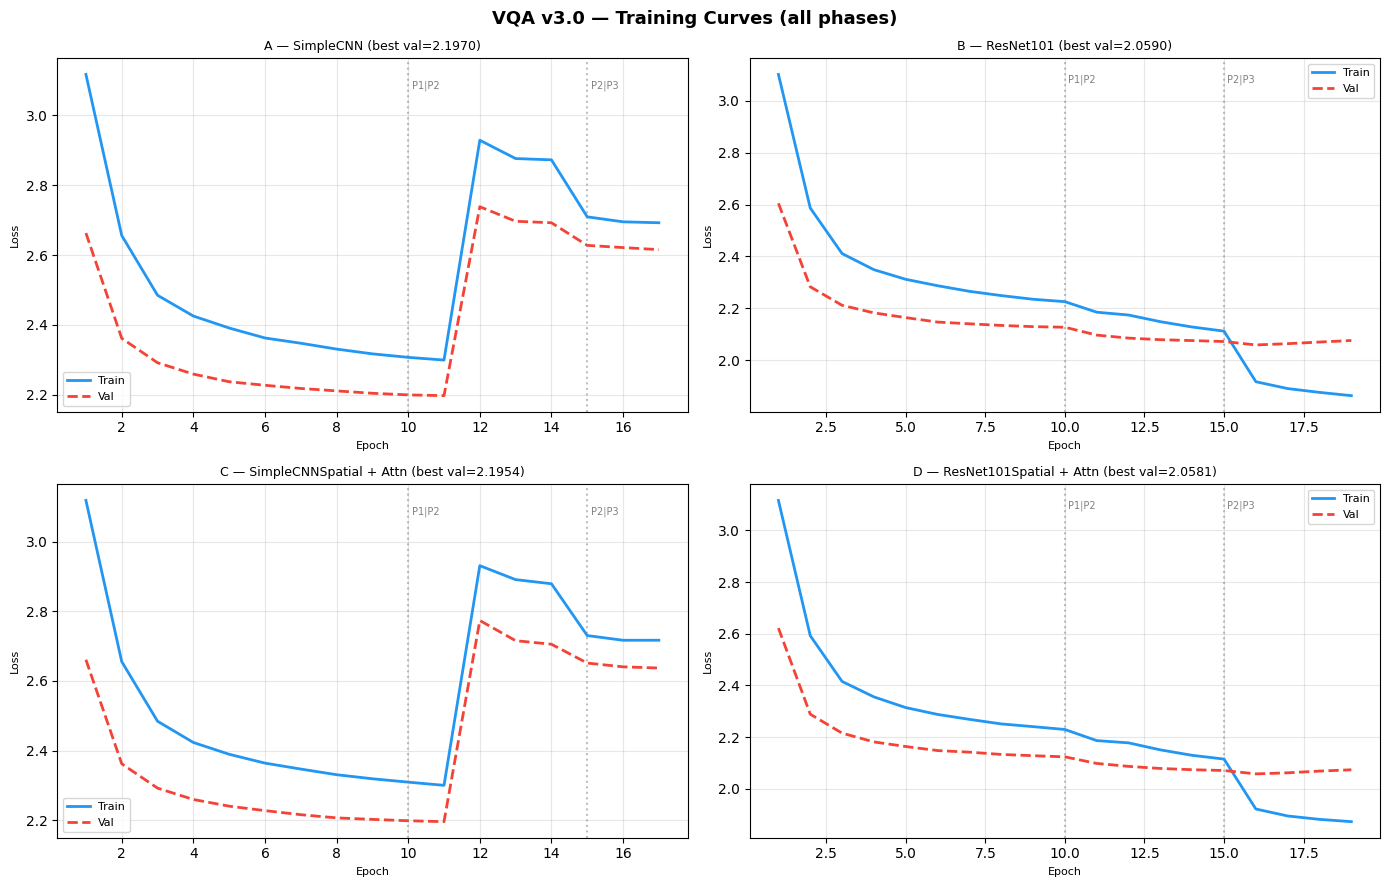

Saved: checkpoints/training_curves_v3.png


In [ ]:
import json, os
import matplotlib.pyplot as plt

model_labels = {
    'a': 'A — SimpleCNN',
    'b': 'B — ResNet101',
    'c': 'C — SimpleCNNSpatial + Attn',
    'd': 'D — ResNet101Spatial + Attn',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('VQA v3.0 — Training Curves (all phases)', fontsize=13, fontweight='bold')

for ax, m in zip(axes.flatten(), ['a', 'b', 'c', 'd']):
    path = f'checkpoints/history_model_{m}.json'
    if not os.path.exists(path):
        ax.text(0.5, 0.5, 'Not trained yet', ha='center', va='center',
                transform=ax.transAxes, color='gray', fontsize=11)
        ax.set_title(model_labels[m])
        continue

    h  = json.load(open(path))
    tl = h['train_loss']
    vl = h['val_loss']
    ep = range(1, len(tl) + 1)

    ax.plot(ep, tl, '#2196F3', lw=2, label='Train')
    ax.plot(ep, vl, '#F44336', lw=2, ls='--', label='Val')

    # Phase separators
    for x, label in [(10, 'P1|P2'), (15, 'P2|P3')]:
        if x < len(tl):
            ax.axvline(x, color='gray', ls=':', alpha=0.5)
            ax.text(x + 0.1, ax.get_ylim()[1] * 0.98, label,
                    color='gray', fontsize=7, va='top')

    ax.set_title(f'{model_labels[m]} (best val={min(vl):.4f})', fontsize=9)
    ax.set_xlabel('Epoch', fontsize=8)
    ax.set_ylabel('Loss', fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('checkpoints/training_curves_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: checkpoints/training_curves_v3.png')

---
## 9 · Attention Visualization (Models C & D)

One key advantage of attention-based models is **interpretability**. The attention weights $\alpha \in \mathbb{R}^{49}$ at each decode step can be reshaped to a 7×7 heatmap and overlaid on the original image, showing **which spatial regions the model focuses on** when generating each answer token.

This provides qualitative evidence of whether the model has learned meaningful visual grounding — for example, attending to a dog when answering "What animal is in the picture?"

In [ ]:
!python src/visualize.py \
    --model_type C \
    --epoch 20 \
    --sample_idx 0 \
    --output checkpoints/attn_model_c.png

Checkpoint not found: checkpoints/model_c_epoch20.pth


In [ ]:
!python src/visualize.py \
    --model_type D \
    --epoch 20 \
    --sample_idx 0 \
    --output checkpoints/attn_model_d.png

Question : What is this photo taken looking through?
Answer   : <unk>
Saved    : checkpoints/attn_model_d.png


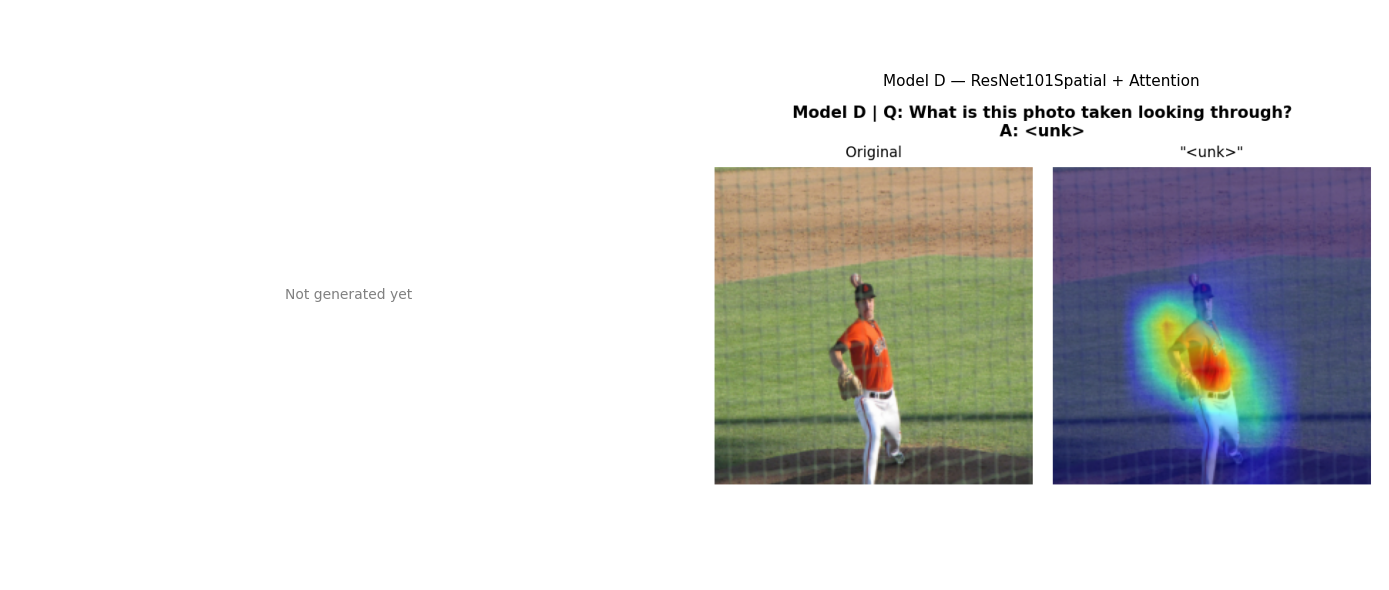

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (path, title) in zip(axes, [
    ('checkpoints/attn_model_c.png', 'Model C — SimpleCNNSpatial + Attention'),
    ('checkpoints/attn_model_d.png', 'Model D — ResNet101Spatial + Attention'),
]):
    if os.path.exists(path):
        ax.imshow(mpimg.imread(path))
        ax.set_title(title, fontsize=11)
    else:
        ax.text(0.5, 0.5, 'Not generated yet', ha='center', va='center',
                transform=ax.transAxes, color='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## 10 · Interactive Inference Demo

This section provides an interactive inference pipeline to test trained models on arbitrary images and questions. It loads the **best checkpoint** (lowest validation loss) for each model and runs **greedy decoding** (or attention-based greedy decoding for Models C & D).

**Usage:** Modify `sample_img` and `question` variables to test different image-question pairs.

In [ ]:
import torch, os, sys, glob, random
sys.path.insert(0, 'src')

from vocab import Vocabulary
from models.vqa_models import VQAModelA, VQAModelB, VQAModelC, VQAModelD
from inference import batch_greedy_decode, batch_greedy_decode_with_attention
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

vocab_q = Vocabulary(); vocab_q.load('data/processed/vocab_questions.json')
vocab_a = Vocabulary(); vocab_a.load('data/processed/vocab_answers.json')

img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

model_cls = {'A': VQAModelA, 'B': VQAModelB, 'C': VQAModelC, 'D': VQAModelD}

def load_model(model_type, ckpt=None):
    if ckpt is None:
        ckpt = f'checkpoints/model_{model_type.lower()}_best.pth'
    if not os.path.exists(ckpt):
        print(f'Checkpoint not found: {ckpt}')
        return None
    model = model_cls[model_type](
        vocab_size=len(vocab_q), answer_vocab_size=len(vocab_a), dropout=0.0
    ).to(DEVICE)
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    model.eval()
    print(f'Loaded Model {model_type} from {ckpt}')
    return model

def predict(model, model_type, image_path, question, max_len=20):
    """Run inference on a single image+question pair and return the answer string."""
    img   = Image.open(image_path).convert('RGB')
    img_t = img_transform(img).unsqueeze(0).to(DEVICE)   # (1, 3, 224, 224)
    q_ids = vocab_q.numericalize(question)
    q_t   = torch.tensor(q_ids, dtype=torch.long).unsqueeze(0).to(DEVICE)  # (1, seq_len)
    with torch.no_grad():
        if model_type in ('C', 'D'):
            answers = batch_greedy_decode_with_attention(
                model, img_t, q_t, vocab_a, max_len=max_len, device=DEVICE)
        else:
            answers = batch_greedy_decode(
                model, img_t, q_t, vocab_a, max_len=max_len, device=DEVICE)
    return answers[0]  # batch functions return list[str], take the first

print('Inference helpers loaded.')

Inference helpers loaded.


Image    : COCO_val2014_000000004760.jpg
Question : What is in the image?

Loaded Model A from checkpoints/model_a_best.pth
Model A : <unk>
Loaded Model A from checkpoints/model_a_best.pth
Model A : <unk>
Loaded Model B from checkpoints/model_b_best.pth
Model B : fire hydrant
Loaded Model B from checkpoints/model_b_best.pth
Model B : fire hydrant
Loaded Model C from checkpoints/model_c_best.pth
Model C : woman
Loaded Model C from checkpoints/model_c_best.pth
Model C : woman
Loaded Model D from checkpoints/model_d_best.pth
Model D : fire hydrant
Loaded Model D from checkpoints/model_d_best.pth
Model D : fire hydrant


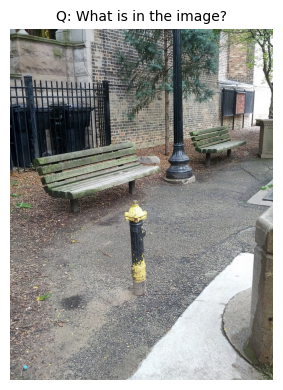

In [ ]:
# Pick a random val image and run all 4 models
val_images = glob.glob('data/val2014/COCO_val2014_*.jpg')
sample_img = random.choice(val_images)
question   = 'What is in the image?'  # Change this to any question

print(f"Image    : {os.path.basename(sample_img)}")
print(f"Question : {question}")
print()

for mt in ['A', 'B', 'C', 'D']:
    m = load_model(mt)
    if m is None:
        continue
    ans = predict(m, mt, sample_img, question)
    print(f"Model {mt} : {ans}")
    del m
    torch.cuda.empty_cache()

# Display image
img = plt.imread(sample_img)
plt.figure(figsize=(5, 4))
plt.imshow(img)
plt.title(f'Q: {question}', fontsize=10)
plt.axis('off')
plt.tight_layout()
plt.show()

---
## 11 · Checkpoint Management & Resume Guide

This section provides an overview of all saved checkpoints and their metadata. The training pipeline automatically saves:

- **`model_X_resume.pth`** — Full training state (model + optimizer + scheduler + scaler + epoch + history) saved every epoch for seamless resumption
- **`model_X_best.pth`** — Model weights only, saved when validation loss reaches a new minimum
- **`model_X_epochN.pth`** — Model weights at milestone epochs (10, 15, 20) for cross-phase comparison

In [ ]:
import torch, os, json

print("Checkpoint status:")
print(f"{'File':<45} {'Size MB':>8} {'Epoch':>6} {'Best Val':>10}")
print("-" * 72)

import glob
for p in sorted(glob.glob('checkpoints/*.pth')):
    mb = os.path.getsize(p) / 1024**2
    try:
        d = torch.load(p, map_location='cpu')
        if isinstance(d, dict) and 'epoch' in d:
            ep  = d.get('epoch', '-')
            bv  = d.get('best_val_loss', float('inf'))
            bvs = f'{bv:.4f}' if bv < 1e9 else '-'
        else:
            ep, bvs = '-', '-'
    except Exception:
        ep, bvs = '?', '?'
    print(f"  {os.path.basename(p):<43} {mb:>7.1f}  {str(ep):>6}  {bvs:>10}")

Checkpoint status:
File                                           Size MB  Epoch   Best Val
------------------------------------------------------------------------
  model_a_best.pth                              185.8       -           -
  model_a_epoch10.pth                           185.8       -           -
  model_a_epoch15.pth                           185.8       -           -
  model_a_epoch19.pth                           185.8       -           -
  model_a_resume.pth                            557.4      17      2.1970
  model_b_best.pth                              328.6       -           -
  model_b_epoch10.pth                           328.6       -           -
  model_a_resume.pth                            557.4      17      2.1970
  model_b_best.pth                              328.6       -           -
  model_b_epoch10.pth                           328.6       -           -
  model_b_epoch15.pth                           328.6       -           -
  model_b_epoch20.pth

### Resuming After Interruption

Each epoch automatically saves `checkpoints/model_X_resume.pth` containing the full training state. To resume training after an interruption, simply re-run the corresponding training cell — the `--resume` flag is already configured.

The resume mechanism:
1. Loads model weights, optimizer state, scheduler state, AMP scaler state, and epoch counter
2. Continues training from the exact point of interruption
3. If the optimizer layout has changed (e.g., Phase 1 → Phase 2 adds backbone params), it automatically detects the mismatch and creates a fresh optimizer with the new learning rate settings

**No data re-processing or vocabulary re-building is needed.**

---

## Appendix: Hardware Configuration Reference

### Batch Size Strategy — RTX 3060 (12 GB VRAM)

The physical `batch_size` varies by model and phase to fit within VRAM, but **gradient accumulation** ensures a consistent effective batch size of 256 across all configurations:

| Model | Phase | `batch_size` | `grad_accum` | Effective BS | VRAM Usage |
|-------|-------|-------------|-------------|-------------|------------|
| A | 1, 2 | 128 | 2 | 256 | ~6 GB |
| B | 1 | 128 | 2 | 256 | ~7 GB (ResNet frozen) |
| B | 2 | 64 | 4 | 256 | ~10 GB (ResNet unfrozen) |
| C | 1, 2 | 64 | 4 | 256 | ~8 GB (attention loop) |
| D | 1 | 64 | 4 | 256 | ~9 GB (ResNet + attention) |
| D | 2 | 32 | 8 | 256 | ~11 GB (everything unfrozen) |
| All | 3 (SS) | 32–64 | 4–8 | 256 | Step-by-step decode |

### Key Training Settings

| Setting | Value | Rationale |
|---------|-------|-----------|
| `num_workers` | 8 | i7-14700K has 20 logical cores — 8 data loader workers |
| AMP dtype | BF16 | RTX 3060 = Ampere CC 8.6 — native BF16, no GradScaler |
| `ss_k` | 2 | Fast epsilon decay for short 5-epoch Phase 3 |
| Checkpoints | Milestone (10, 15, 20) + best + resume | Full reproducibility and comparison support |